# Total Spend Prediction
### Regression Modeling Using Customer Profile Data Only

## 1. Problem Overview and Analytical Framing

Understanding and predicting customer spending behavior is a central task in customer analytics and data-driven marketing. Accurately estimating **TotalSpend** enables businesses to improve customer segmentation, allocate marketing resources more effectively, and support strategic decision-making.

In this notebook, the objective is to predict **TotalSpend** at the individual customer level using **customer profile data only**. The available information is limited to demographic, socioeconomic, and household-related characteristics, reflecting a realistic scenario in which detailed purchase histories or behavioral tracking data are not accessible at modeling time.

Under this setting, customer spending is modeled as a function of *who the customer is*, rather than *how the customer has previously interacted with the company*. This framing allows for an explicit assessment of how much predictive power can be extracted from static profile attributes alone, and provides a meaningful benchmark against richer, behavior-informed models.

The problem is formulated as a **supervised regression task**, where TotalSpend is constructed as an aggregate measure of monetary value across multiple product categories. Key challenges include handling skewed spending distributions, heterogeneous feature types, and potentially weak or indirect relationships between profile variables and spending outcomes.

To address these challenges, the analysis follows a structured and reproducible workflow, progressing from data preparation and feature engineering to a systematic comparison of regression models with increasing levels of complexity. All preprocessing and transformation steps are applied in a leakage-safe manner, with model performance evaluated consistently across approaches to ensure fair and interpretable comparisons.



## 2. Technical Setup and Utilities

### 2.1 Imports

In [1]:
# ============================================================
# 📦 Core Scientific Stack
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# 📊 Visualization
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ============================================================
# 📐 Statistics & Statistical Modeling
# ============================================================
import scipy.stats as stats
import statsmodels.api as sm

# ============================================================
# 🤖 Machine Learning — Core Utilities
# ============================================================
from sklearn.model_selection import (KFold, cross_val_score, GridSearchCV, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, PolynomialFeatures)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# ============================================================
# 🧱 Preprocessing & Pipelines
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# ============================================================
# 📈 Linear & Regularized Models
# ============================================================
from sklearn.linear_model import (LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV)

# ============================================================
# 🌳 Tree-Based Models
# ============================================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor)

# ============================================================
# 🌊 Kernel-Based Models
# ============================================================
from sklearn.svm import SVR

# ============================================================
# 🚀 Gradient Boosting (External)
# ============================================================
from xgboost import XGBRegressor

# ============================================================
# 🚨 Anomaly Detection (used in EDA / preprocessing)
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# ============================================================
# 🛠 Utilities & Configuration
# ============================================================
import os
import re
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 🎨 Project Styling
# ============================================================
MAIN_COLOR = "#B388EB"


### 2.2 IQR-Based Outlier Handling Utilities

In [2]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        # Ensure DataFrame for column-wise operations
        X = pd.DataFrame(X)

        # Store feature names for later use
        self.feature_names_in_ = X.columns.to_numpy()

        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1

        self.lower_bounds_ = q1 - self.k * iqr
        self.upper_bounds_ = q3 + self.k * iqr

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_).copy()

        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )

        return X

    def get_feature_names_out(self, input_features=None):
        # sklearn-compatible feature name passthrough
        if input_features is not None:
            return np.array(input_features)
        return self.feature_names_in_


## 3. Data Preparation and Pipeline-Based Preprocessing

### 3.1 Load Raw Data

In [3]:
# Load raw marketing campaign dataset
df = pd.read_csv('Data/marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### 3.2 Basic Data Cleaning

Only minimal data cleaning is performed at this stage, including
type corrections (e.g. date fields).

A more extensive exploratory data analysis (EDA) was previously conducted
on the full dataset and is documented in a separate notebook
([eda.ipynb](eda.ipynb)).
Insights from that analysis informed feature selection and modeling decisions,
but the analysis itself is not repeated here.

In [4]:
# ----------------------------------
# 1.2 Basic Data Cleaning
# ----------------------------------

# Convert customer registration date to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)


### 3.3 Train / Test Split

In [5]:
# ----------------------------------
# 3.3 Train / Test Split
# ----------------------------------

# Keep raw dataframe split (no target construction here)
X_train, X_test = train_test_split(
    df,
    test_size=0.20,
    random_state=1234
)

# Sanity check
X_train.shape, X_test.shape

((1792, 29), (448, 29))

### 3.4 Target Construction (TotalSpend)

The regression target **TotalSpend** is not available as a single column in the
raw dataset and is therefore constructed explicitly as the sum of customer
spending across all product categories.

Target construction is performed **after the train / test split** and **outside
of any preprocessing pipelines** to preserve a clear conceptual separation
between target definition and feature engineering, and to avoid any form of data
leakage.

Due to the strong right skewness of spending behavior, the target variable is
log-transformed using `log1p` separately for the training and test sets. This
transformation stabilizes variance and improves model robustness while
preserving zero-spend observations.


In [7]:
# ----------------------------------
# 3.4 Target Construction
# ----------------------------------

# Spending columns used to define the target
spend_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Construct target for train and test sets
#y_train = X_train[spend_cols].sum(axis=1)
#y_test = X_test[spend_cols].sum(axis=1)

y_train_raw = X_train[spend_cols].sum(axis=1)
y_test_raw  = X_test[spend_cols].sum(axis=1)

y_train = np.log1p(y_train_raw)
y_test  = np.log1p(y_test_raw)

# Sanity check
y_train.shape, y_test.shape


((1792,), (448,))

### 3.5 Deterministic Feature Construction

At this stage, deterministic (rule-based) features are constructed using a
custom transformer. These features do not require learning from the data and
can be safely applied after the train / test split.

The transformer encapsulates domain-driven feature engineering logic (e.g.
temporal, demographic, household, and campaign-related features) and is
designed to be fully reusable and pipeline-compatible.

In [8]:
# ----------------------------------
# 3.5 Deterministic Feature Construction
# ----------------------------------

from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DeterministicFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Custom transformer for deterministic, rule-based feature construction.
    Leakage-safe: no target information is used.
    """

    def fit(self, X, y=None):
        # Reference points derived from training data only
        self.reference_year_ = X["Dt_Customer"].dt.year.max()
        self.reference_date_ = X["Dt_Customer"].max()
        return self

    def transform(self, X):
        X_ = X.copy()

        # ------------------
        # Temporal features
        # ------------------
        X_["Age"] = self.reference_year_ - X_["Year_Birth"]

        X_["Tenure_Days"] = (self.reference_date_ - X_["Dt_Customer"]).dt.days
        X_["Tenure_Months"] = (X_["Tenure_Days"] / 30).round().astype(int)

        # ------------------
        # Household & demographic
        # ------------------
        X_["Marital_Status"] = X_["Marital_Status"].replace(
            ['Alone', 'Absurd', 'YOLO'], 'Other'
        )

        X_["HasChildren"] = (
            (X_["Kidhome"] + X_["Teenhome"]) > 0
        ).astype(int)

        X_["FamilySize"] = (
            X_["Marital_Status"].isin(['Married', 'Together']).astype(int)
            + 1
            + X_["Kidhome"]
            + X_["Teenhome"]
        )

        # ------------------
        # Education
        # ------------------
        education_map = {
            'Basic': 1,
            '2n Cycle': 2,
            'Graduation': 3,
            'Master': 4,
            'PhD': 5
        }

        X_["Education_Level"] = X_["Education"].map(education_map)

        X_["Education_Level_Grouped"] = pd.cut(
            X_["Education_Level"],
            bins=[0, 2, 4, 5],
            labels=["Low", "Medium", "High"]
        )

        # ------------------
        # Purchase behavior
        # ------------------
        purchase_cols = [
            'NumWebPurchases',
            'NumCatalogPurchases',
            'NumStorePurchases'
        ]
        X_["TotalPurchases"] = X_[purchase_cols].sum(axis=1)

        # ------------------
        # Campaign behavior
        # ------------------
        accepted_cols = [
            'AcceptedCmp1',
            'AcceptedCmp2',
            'AcceptedCmp3',
            'AcceptedCmp4',
            'AcceptedCmp5'
        ]
        X_["TotalAccepted"] = X_[accepted_cols].sum(axis=1)

        return X_


### 3.6 Feature Group Definition

For the profile-only regression setting, features are grouped according to the preprocessing operations applied to each variable, such as capping, scaling, or categorical encoding.

Only static customer profile attributes are included at this stage. Variables related to purchasing behavior, campaign interaction, or customer tenure are intentionally excluded to preserve a strict separation between profile-based and behavior-based modeling.

This feature grouping is fully aligned with prior EDA findings and is independent of any target transformation. The regression target (TotalSpend) will be transformed later within model-specific pipelines where appropriate.

In [9]:
# ----------------------------------
# 3.6 Feature Group Definition
# Profile-only setting
# ----------------------------------

# Numeric continuous features
# - Subject to IQR-based capping and scaling
numeric_continuous_cols = [
    "Income",
    "Age"
]

# Numeric household structure features
# - Discrete counts, kept on original scale or lightly scaled
numeric_household_cols = [
    "Kidhome",
    "Teenhome"
]

# Categorical profile features (low cardinality)
categorical_cols = [
    "Education",
    "Marital_Status"
]



### 3.7 Preprocessing Pipelines by Model Family

To ensure fair and leakage-safe model comparison, preprocessing is defined **at the model-family level** rather than individually per model.  
Each family applies transformations that are aligned with its underlying assumptions and sensitivity to feature scale, distribution, and sparsity.

The pipelines reuse the feature groups defined in Section 3.6 and differ mainly in:
- Whether scaling is required
- Whether categorical variables are included
- How non-linear effects are handled (explicit vs. implicit)

All preprocessing steps are fitted **exclusively on the training data** within each pipeline.


In [10]:
# ----------------------------------
# 3.7 Preprocessing Pipelines by Model Family
# ----------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ============================================================
# Family 1 — Linear & Regularized Linear Models
# Models:
#   LinearRegression, Ridge, Lasso, LassoCV
# ============================================================

linear_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("capper", IQRCapper()),
        ("scaler", StandardScaler())
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]),
    "categorical": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ])
}

# ============================================================
# Family 2 — Polynomial Linear Models
# Models:
#   Polynomial Linear, Polynomial Ridge, Polynomial Lasso
# ============================================================

poly_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("capper", IQRCapper())
        # PolynomialFeatures is applied later in the model pipeline
        # Scaling is applied AFTER polynomial expansion
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
        # No capping for count features
        # PolynomialFeatures is applied later
    ]),
    "categorical": "drop"
}

# ============================================================
# Family 3 — Tree-Based Models
# Models:
#   DecisionTree, RandomForest, GradientBoosting, XGBoost
# ============================================================

tree_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]),
    "categorical": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
}

# ============================================================
# Family 4 — Support Vector Regression (SVR)
# Models:
#   SVR (RBF) on selected feature subsets
# ============================================================

svr_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]),
    "categorical": "drop"
}


### 3.8 Preprocessors (ColumnTransformer)

This section binds feature groups (Section 3.6)mto preprocessing pipelines defined in Section 3.7.
Each preprocessor is used by a specific model family.

In [11]:
# ----------------------------------
# 3.8 Preprocessors (ColumnTransformer) by Model Family
# ----------------------------------
# PROFILE-ONLY SETUP
# Feature groups:
#   - numeric_continuous_cols (Income_capped, Age_capped)
#   - numeric_household_cols (Kidhome, Teenhome)
#   - categorical_cols (Education, Marital_Status)

from sklearn.compose import ColumnTransformer

# ============================================================
# Preprocessor 1 — Linear & Regularized Linear Models
# Models:
#   LinearRegression, Ridge, Lasso, LassoCV
# ============================================================
# - Continuous numeric: capped + scaled
# - Household numeric: scaled
# - Categorical: one-hot encoded

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num_cont", linear_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", linear_pipelines["numeric_household"], numeric_household_cols),
        ("cat", linear_pipelines["categorical"], categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# Preprocessor 2 — Polynomial Linear Models
# Models:
#   Polynomial Linear, Polynomial Ridge, Polynomial Lasso
# ============================================================
# - Only numeric profile features
# - Polynomial expansion applied later in model pipeline

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num_cont", poly_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", poly_pipelines["numeric_household"], numeric_household_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# Preprocessor 3 — Tree-Based Models
# Models:
#   DecisionTree, RandomForest, GradientBoosting, XGBoost
# ============================================================
# - No scaling
# - Raw numeric profile features
# - Categorical features one-hot encoded

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num_cont", tree_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", tree_pipelines["numeric_household"], numeric_household_cols),
        ("cat", tree_pipelines["categorical"], categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# Preprocessor 4 — Support Vector Regression (SVR)
# Models:
#   SVR (RBF)
# ============================================================
# - All numeric features scaled
# - Categorical features excluded

preprocessor_svr = ColumnTransformer(
    transformers=[
        ("num_cont", svr_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", svr_pipelines["numeric_household"], numeric_household_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [12]:
preprocessor_linear

,transformers,"[('num_cont', ...), ('num_house', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [13]:
preprocessor_poly

,transformers,"[('num_cont', ...), ('num_house', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [14]:
preprocessor_tree

,transformers,"[('num_cont', ...), ('num_house', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [15]:
preprocessor_svr

,transformers,"[('num_cont', ...), ('num_house', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 4. Modeling

In this section, a comprehensive set of regression models is developed to predict TotalSpend, under the assumption that only customer profile information is available at modeling time.

The modeling setup reflects a realistic business scenario in which spending predictions must be made based solely on static customer attributes, such as demographic, socioeconomic, and household characteristics (e.g. age, income, education, and household structure), without access to historical purchase behavior or transactional signals.

All models therefore operate on a profile-only feature space, constructed and preprocessed in the previous sections. This design allows for a focused evaluation of how much predictive power can be extracted from customer profiles alone, and establishes a clear baseline for comparison with richer, behavior-informed models analyzed in subsequent notebooks.

Rather than committing to a single modeling approach upfront, this section follows a structured, learning-oriented progression across multiple model families. Each family embodies different assumptions about the underlying relationship between profile attributes and customer spending — ranging from linear and additive effects to non-linear, interaction-based patterns.

Models are organized by increasing complexity and inductive bias, enabling a systematic comparison of interpretability, flexibility, and generalization performance. All preprocessing steps and model evaluations are conducted in a leakage-safe manner, with transformations fitted exclusively on the training data.

The objective of this section is not only to identify the best-performing profile-based regression model, but also to understand how predictive performance evolves as model complexity increases, and to assess the practical limits of profile-only information for predicting customer spending behavior.


### 4.1 Linear and Regularized Linear Models (Models 1–6)

#### Model 1 — Linear Regression (Baseline)

In [16]:
# ============================================================
# Model 1 — Linear Regression (Baseline)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Pipeline (reuse existing feature builder + preprocessor)
# ------------------------------------------------------------

pipe_lr_m1 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_linear),  # defined in Section 3.8
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m1,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m1.fit(X_train, y_train)

y_train_pred = pipe_lr_m1.predict(X_train)
y_test_pred  = pipe_lr_m1.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust, no refit)
# ------------------------------------------------------------

X_train_built = pipe_lr_m1.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_lr_m1.named_steps["preprocessor"].transform(X_train_built)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Store results (THIS IS THE STANDARD FROM NOW ON)
# ------------------------------------------------------------

results_m1 = {
    "model": "Model 1 — Linear Regression (Baseline)",
    "family": "Linear",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Quick print (optional sanity check)
# ------------------------------------------------------------

print("Model 1 — Linear Regression (Baseline)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 1 — Linear Regression (Baseline)
R² test : 0.713
R² train: 0.694
R² CV   : 0.689


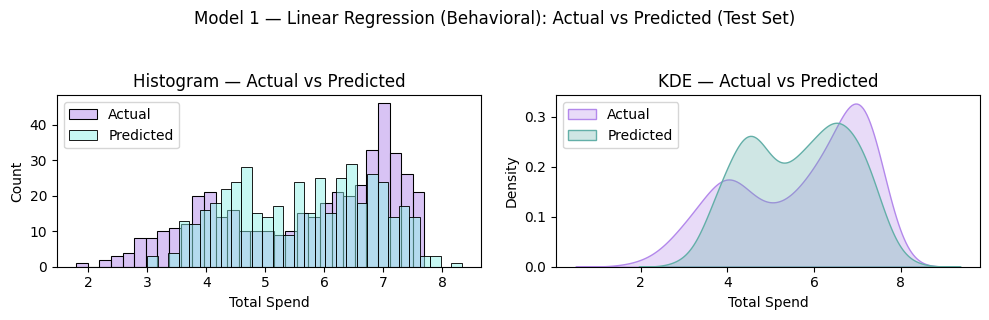

In [17]:
# ============================================================
# Model 1 — Linear Regression (Behavioral)
# Actual vs Predicted (Test Set)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 1 — Linear Regression (Behavioral): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 2 — Linear Regression (EDA-restricted feature set)

In [18]:
# ============================================================
# Model 2 — Linear Regression (EDA-restricted feature subset)
# Same preprocessing logic as Model 1, reduced feature space
# ============================================================

# ------------------------------------------------------------
# EDA-based FEATURE SUBSET (subset of Section 3.6 features)
# ------------------------------------------------------------

numeric_continuous_cols_m2 = [
    "Income",
    "Age"
]

numeric_count_cols_m2 = [
    "Kidhome"
]

categorical_cols_m2 = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (REUSES Family 1 pipelines; columns restricted)
# ------------------------------------------------------------

preprocessor_m2 = ColumnTransformer(
    transformers=[
        ("num_cont", linear_pipelines["numeric_continuous"], numeric_continuous_cols_m2),
        ("num_count", linear_pipelines["numeric_household"], numeric_count_cols_m2),
        ("cat", linear_pipelines["categorical"], categorical_cols_m2),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m2 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m2),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m2,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m2.fit(X_train, y_train)

y_train_pred = pipe_lr_m2.predict(X_train)
y_test_pred  = pipe_lr_m2.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust; use fitted pipeline)
# ------------------------------------------------------------

X_train_built = pipe_lr_m2.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_lr_m2.named_steps["preprocessor"].transform(X_train_built)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m2 = {
    "model": "Model 2 — Linear Regression (EDA-restricted)",
    "family": "Linear",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Quick print
# ------------------------------------------------------------

print("Model 2 — Linear Regression (EDA-restricted)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 2 — Linear Regression (EDA-restricted)
R² test : 0.713
R² train: 0.694
R² CV   : 0.688


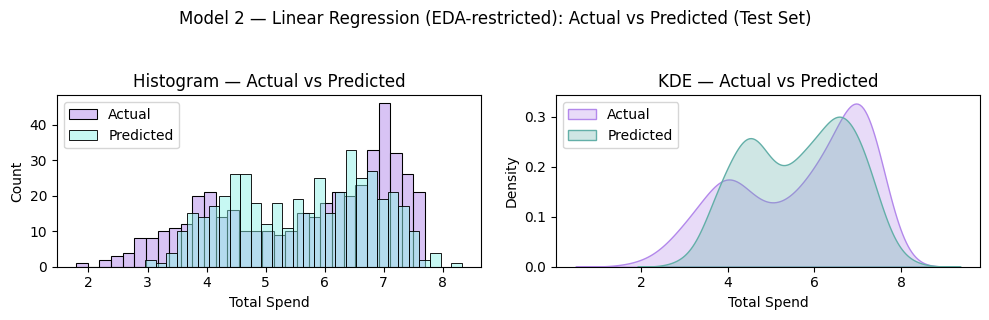

In [19]:
# ============================================================
# Model 2 — Linear Regression (EDA-restricted)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 2 — Linear Regression (EDA-restricted): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 3 — Ridge Regression (Regularized Linear Model)

This model extends linear regression by applying L2 regularization (Ridge)
to mitigate multicollinearity and improve coefficient stability.


In [20]:
# ============================================================
# Model 3 — Ridge Regression (Behavioral, Regularized)
# ============================================================

# ------------------------------------------------------------
# Ridge model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-3, 3, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=cv_inner,
    scoring="r2"
)

# ------------------------------------------------------------
# Pipeline (REUSE locked components)
# ------------------------------------------------------------

pipe_ridge_m3 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_linear),  # (Section 3.8)
    ("regressor", ridge)
])

# ------------------------------------------------------------
# Outer CV (evaluation)
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_ridge_m3,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_ridge_m3.fit(X_train, y_train)

y_train_pred = pipe_ridge_m3.predict(X_train)
y_test_pred  = pipe_ridge_m3.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (use FITTED pipeline — no refit)
# ------------------------------------------------------------

X_train_built = pipe_ridge_m3.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_ridge_m3.named_steps["preprocessor"].transform(X_train_built)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m3 = {
    "model": "Model 3 — Ridge Regression",
    "family": "Linear (Regularized)",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "best_alpha": pipe_ridge_m3.named_steps["regressor"].alpha_,
}

# ------------------------------------------------------------
# Quick print
# ------------------------------------------------------------

print("Model 3 — Ridge Regression")
print(f"Best α  : {pipe_ridge_m3.named_steps['regressor'].alpha_:.5f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 3 — Ridge Regression
Best α  : 33.93222
R² test : 0.712
R² train: 0.694
R² CV   : 0.690


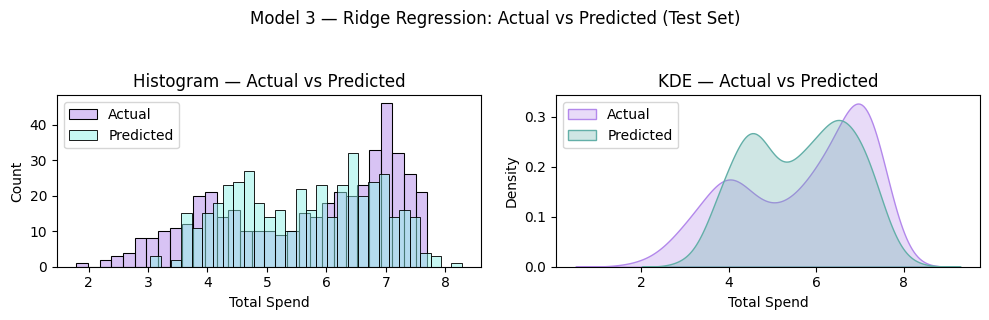

In [21]:
# ============================================================
# Model 3 — Ridge Regression
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 3 — Ridge Regression: Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 4 — Lasso Regression (Automatic Feature Selection)

This model applies L1 regularization (Lasso) to automatically select a sparse
set of informative features by shrinking less relevant coefficients to zero.


In [22]:
# ============================================================
# Model 4 — LassoCV (Behavioral, Feature Selection)
# ============================================================

# ------------------------------------------------------------
# Lasso model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-4, 1, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

lasso = LassoCV(
    alphas=alphas,
    cv=cv_inner,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline (REUSE locked components)
# ------------------------------------------------------------

pipe_lasso_m4 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_linear),  # LOCKED
    ("regressor", lasso)
])

# ------------------------------------------------------------
# Outer CV
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_m4,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_m4.fit(X_train, y_train)

y_train_pred = pipe_lasso_m4.predict(X_train)
y_test_pred  = pipe_lasso_m4.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO coefficients)
# ------------------------------------------------------------

feature_names = (
    pipe_lasso_m4
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefs = pipe_lasso_m4.named_steps["regressor"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if coef != 0
]

selected_sorted = sorted(
    selected, key=lambda x: abs(x[1]), reverse=True
)

n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Feature count (selected features)
# ------------------------------------------------------------

feature_count = n_selected

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m4 = {
    "model": "Model 4 — LassoCV",
    "family": "Linear (L1)",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "best_alpha": pipe_lasso_m4.named_steps["regressor"].alpha_,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 4 — LassoCV")
print(f"Best α  : {pipe_lasso_m4.named_steps['regressor'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected} / {len(feature_names)}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 4 — LassoCV
Best α  : 0.017575
R² test : 0.712
R² train: 0.693
R² CV   : 0.691

Selected features: 4 / 13
  Income                                         coef = +0.9667
  Kidhome                                        coef = -0.3751
  Teenhome                                       coef = -0.0339
  Age                                            coef = -0.0010


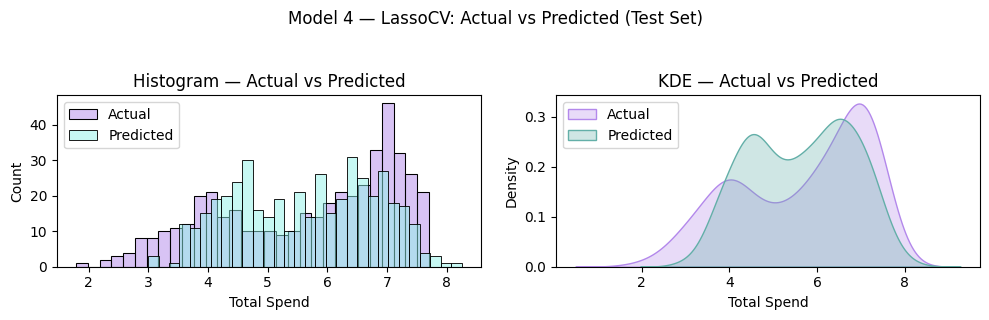

In [23]:
# ============================================================
# Model 4 — LassoCV
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 4 — LassoCV: Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 5 — Lasso Regression (Fixed Alpha)

This model applies L1 regularization with a fixed regularization strength (α),
selected based on the results of LassoCV.  
Fixing α allows for a more stable and interpretable sparse solution.

In [25]:
# ============================================================
# Model 5 — Lasso Regression (Fixed Alpha, Behavioral)
# ============================================================

# ------------------------------------------------------------
# Fixed-alpha Lasso 
# ------------------------------------------------------------

alpha_fixed = 0.02

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline (REUSE locked components)
# ------------------------------------------------------------

pipe_lasso_m5 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_linear),  # LOCKED
    ("regressor", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_m5,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_m5.fit(X_train, y_train)

y_train_pred = pipe_lasso_m5.predict(X_train)
y_test_pred  = pipe_lasso_m5.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO coefficients)
# ------------------------------------------------------------

feature_names = (
    pipe_lasso_m5
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefs = pipe_lasso_m5.named_steps["regressor"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if coef != 0
]

selected_sorted = sorted(
    selected, key=lambda x: abs(x[1]), reverse=True
)

n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Feature count
# ------------------------------------------------------------

feature_count = n_selected

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m5 = {
    "model": "Model 5 — Lasso (Fixed Alpha)",
    "family": "Linear (L1 fixed)",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "alpha_fixed": alpha_fixed,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 5 — Lasso Regression (Fixed Alpha)")
print(f"Alpha fixed: {alpha_fixed:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 5 — Lasso Regression (Fixed Alpha)
Alpha fixed: 0.020000
R² test : 0.711
R² train: 0.693
R² CV   : 0.691

Selected features: 3
  Income                                         coef = +0.9649
  Kidhome                                        coef = -0.3732
  Teenhome                                       coef = -0.0317


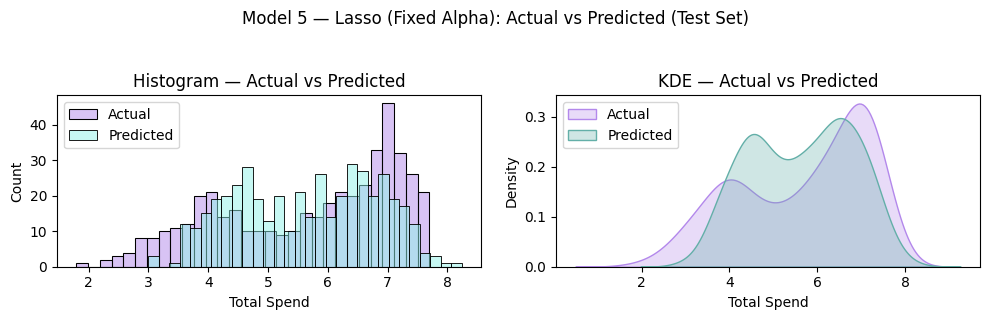

In [26]:
# ============================================================
# Model 5 — Lasso Regression (Fixed Alpha)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 5 — Lasso (Fixed Alpha): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


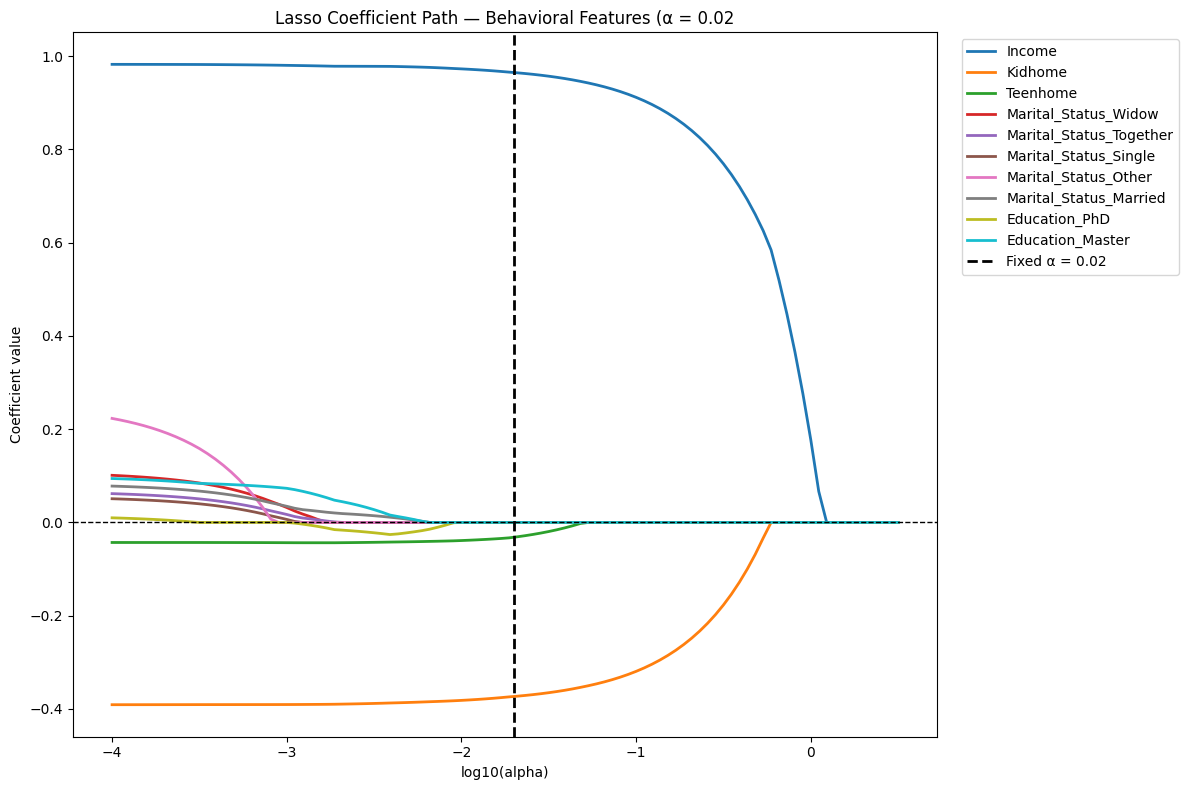

In [31]:
# ============================================================
# Lasso Coefficient Path — Behavioral (Aligned with Model 5)
# ============================================================

# ------------------------------------------------------------
# Prepare design matrix (USING SAME PIPELINE AS MODEL 5)
# ------------------------------------------------------------

X_train_built = DeterministicFeatureBuilder().fit_transform(X_train)
X_train_prepared = preprocessor_linear.fit_transform(X_train_built)

feature_names = preprocessor_linear.get_feature_names_out()

# ------------------------------------------------------------
# Alpha grid (FOCUSED around alpha = 0.02)
# ------------------------------------------------------------

alphas = np.logspace(-4, 0.5, 100)   # 1 → 100 (dense around 0.02)

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=50000)
    lasso.fit(X_train_prepared, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

# ------------------------------------------------------------
# Fixed alpha (Model 5)
# ------------------------------------------------------------

alpha_fixed = 0.02

idx_fixed = np.argmin(np.abs(alphas - alpha_fixed))
coef_at_fixed = coefs[idx_fixed]

# ------------------------------------------------------------
# Select top 10 features by |coef| at fixed alpha
# ------------------------------------------------------------

top_idx_sorted = np.argsort(np.abs(coef_at_fixed))[-10:][::-1]

# ------------------------------------------------------------
# Plot coefficient paths
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

for i in top_idx_sorted:
    plt.plot(
        np.log10(alphas),
        coefs[:, i],
        linewidth=2,
        label=feature_names[i]
    )

plt.axvline(
    np.log10(alpha_fixed),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Fixed α = {alpha_fixed}"
)

plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

y_min = coefs[:, top_idx_sorted].min()
y_max = coefs[:, top_idx_sorted].max()
pad = 0.05 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path — Behavioral Features (α = 0.02")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### Model 6 — Linear Regression (Lasso-selected Features)

This model retrains a linear regression using only the features selected
by Lasso with a fixed regularization strength (α = 13).


In [32]:
# ============================================================
# Model 6 — Linear Regression (Top-3 Lasso-selected, α = 0.02)
# ============================================================

# ------------------------------------------------------------
# Feature subsets (FROM Model 5, α = 0.02)
# ------------------------------------------------------------

numeric_continuous_cols_m6 = [
    "Income"
]

numeric_count_cols_m6 = [
    "Teenhome",
    "Kidhome",
]

# ------------------------------------------------------------
# Preprocessor (REUSE Family 1 pipelines, restricted columns)
# ------------------------------------------------------------

preprocessor_m6 = ColumnTransformer(
    transformers=[
        ("num_cont", linear_pipelines["numeric_continuous"], numeric_continuous_cols_m6),
        ("num_count", linear_pipelines["numeric_household"], numeric_count_cols_m6)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lr_m6 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m6),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m6,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m6.fit(X_train, y_train)

y_train_pred = pipe_lr_m6.predict(X_train)
y_test_pred  = pipe_lr_m6.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (pipeline-consistent)
# ------------------------------------------------------------

X_train_built = pipe_lr_m6.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_lr_m6.named_steps["preprocessor"].transform(X_train_built)
feature_count = X_train_transformed.shape[1]   # should be 8

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m6 = {
    "model": "Model 6 — Linear Regression (Top-3 Lasso-selected)",
    "family": "Linear (Post-Lasso)",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 6 — Linear Regression (Top-3 Lasso-selected)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Features used: {feature_count}")


Model 6 — Linear Regression (Top-3 Lasso-selected)
R² test : 0.712
R² train: 0.693
R² CV   : 0.692
Features used: 3


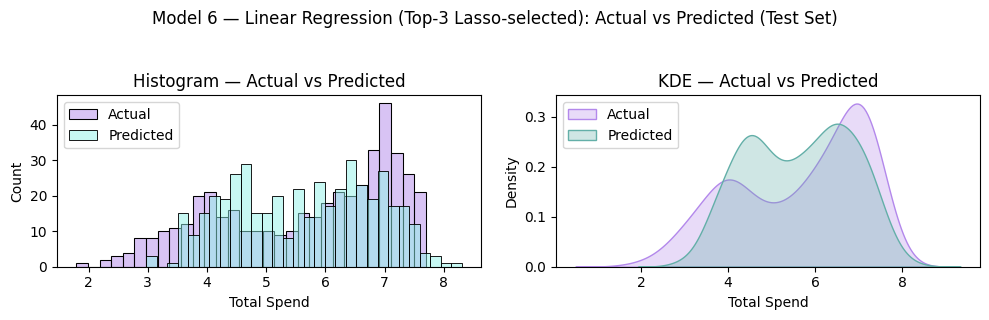

In [33]:
# ============================================================
# Model 6 — Linear Regression (Top-3 Lasso-selected)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 6 — Linear Regression (Top-3 Lasso-selected): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


### 4.2. Polynomial Regression Models (Models 7–11)

To capture non-linear effects and pairwise interactions, polynomial regression
(degree = 2) is applied.
Both unregularized and regularized (Ridge, Lasso) variants are evaluated to control
overfitting, using the same leakage-safe framework as previous models.

#### Model 7 — Polynomial Linear Regression (degree = 2)

In [34]:
# ============================================================
# Model 7 — Polynomial Linear Regression (degree = 2)
# ============================================================

# ------------------------------------------------------------
# Pipeline (Polynomial on numeric_continuous + numeric_count)
# ------------------------------------------------------------

pipe_poly_m7 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly),   # LOCKED (Family 2)
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_poly_m7,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_poly_m7.fit(X_train, y_train)

y_train_pred = pipe_poly_m7.predict(X_train)
y_test_pred  = pipe_poly_m7.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (PIPELINE-CONSISTENT)
# ------------------------------------------------------------

X_train_built = pipe_poly_m7.named_steps["feature_builder"].transform(X_train)
X_train_pre   = pipe_poly_m7.named_steps["preprocessor"].transform(X_train_built)
X_train_poly  = pipe_poly_m7.named_steps["poly"].transform(X_train_pre)

feature_count = X_train_poly.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m7 = {
    "model": "Model 7 — Polynomial Linear Regression (deg=2)",
    "family": "Polynomial Linear",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 7 — Polynomial Linear Regression (deg=2)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Total features after polynomial expansion: {feature_count}")


Model 7 — Polynomial Linear Regression (deg=2)
R² test : 0.720
R² train: 0.719
R² CV   : 0.713
Total features after polynomial expansion: 14


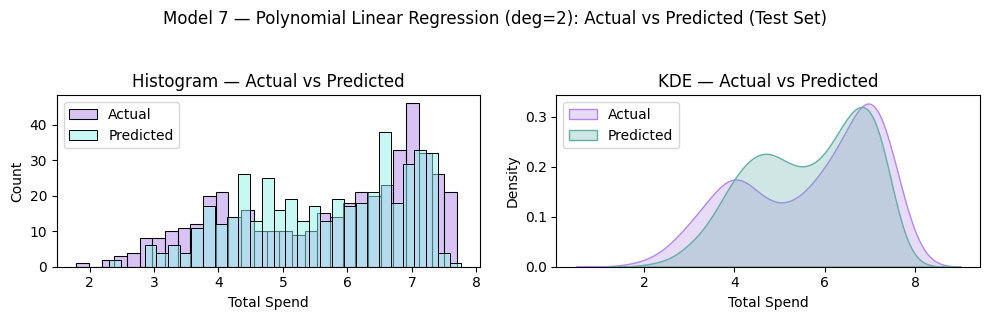

In [35]:
# ============================================================
# Model 7 — Polynomial Linear Regression (deg=2)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 7 — Polynomial Linear Regression (deg=2): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 8 — Polynomial Ridge Regression (degree = 2)

In [36]:
# ============================================================
# Model 8 — Polynomial Ridge Regression (degree = 2)
# ============================================================

# ------------------------------------------------------------
# RidgeCV (regularization on polynomial space)
# ------------------------------------------------------------

alphas = np.logspace(-2, 2, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=cv_inner,
    scoring="r2"
)

# ------------------------------------------------------------
# Pipeline (SAME AS Model 7 + Ridge)
# ------------------------------------------------------------

pipe_poly_ridge_m8 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly),   # LOCKED (Family 2)
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", ridge_cv)
])

# ------------------------------------------------------------
# Cross-validation (outer)
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_poly_ridge_m8,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_poly_ridge_m8.fit(X_train, y_train)

y_train_pred = pipe_poly_ridge_m8.predict(X_train)
y_test_pred  = pipe_poly_ridge_m8.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (PIPELINE-CONSISTENT)
# ------------------------------------------------------------

X_train_built = pipe_poly_ridge_m8.named_steps["feature_builder"].transform(X_train)
X_train_pre   = pipe_poly_ridge_m8.named_steps["preprocessor"].transform(X_train_built)
X_train_poly  = pipe_poly_ridge_m8.named_steps["poly"].transform(X_train_pre)

feature_count = X_train_poly.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m8 = {
    "model": "Model 8 — Polynomial Ridge Regression (deg=2)",
    "family": "Polynomial Ridge",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "best_alpha": pipe_poly_ridge_m8.named_steps["regressor"].alpha_,
}

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 8 — Polynomial Ridge Regression (deg=2)")
print(f"Best α  : {pipe_poly_ridge_m8.named_steps['regressor'].alpha_:.4f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Total features after polynomial expansion: {feature_count}")


Model 8 — Polynomial Ridge Regression (deg=2)
Best α  : 1.0985
R² test : 0.720
R² train: 0.719
R² CV   : 0.713
Total features after polynomial expansion: 14


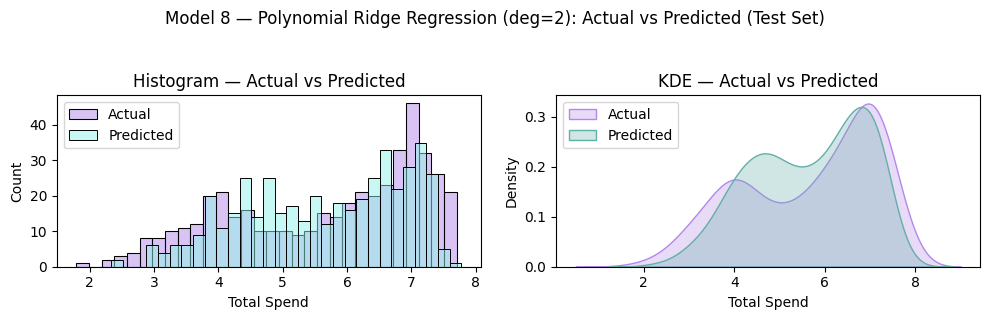

In [37]:
# ============================================================
# Model 8 — Polynomial Ridge Regression (deg=2)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 8 — Polynomial Ridge Regression (deg=2): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 9 — Polynomial LassoCV (degree = 2)

In [38]:
# ============================================================
# Model 9 — Polynomial LassoCV (degree = 2)
# ============================================================

# ------------------------------------------------------------
# LassoCV (regularization + feature selection in poly space)
# ------------------------------------------------------------

alphas = np.logspace(-3, 1, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=cv_inner,
    max_iter=100000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline (SAME AS Model 7 & 8 + LassoCV)
# ------------------------------------------------------------

pipe_poly_lasso_m9 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly),   # LOCKED (Family 2)
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", lasso_cv)
])

# ------------------------------------------------------------
# Cross-validation (outer)
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_poly_lasso_m9,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_poly_lasso_m9.fit(X_train, y_train)

y_train_pred = pipe_poly_lasso_m9.predict(X_train)
y_test_pred  = pipe_poly_lasso_m9.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO coefficients)
# ------------------------------------------------------------

X_train_built = pipe_poly_lasso_m9.named_steps["feature_builder"].transform(X_train)
X_train_pre   = pipe_poly_lasso_m9.named_steps["preprocessor"].transform(X_train_built)
X_train_poly  = pipe_poly_lasso_m9.named_steps["poly"].transform(X_train_pre)

feature_names = pipe_poly_lasso_m9.named_steps["poly"].get_feature_names_out(
    pipe_poly_lasso_m9.named_steps["preprocessor"].get_feature_names_out()
)

coefs = pipe_poly_lasso_m9.named_steps["regressor"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if abs(coef) > 1e-8
]

selected_sorted = sorted(
    selected, key=lambda x: abs(x[1]), reverse=True
)

feature_count = len(selected_sorted)

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m9 = {
    "model": "Model 9 — Polynomial LassoCV (deg=2)",
    "family": "Polynomial Lasso",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "best_alpha": pipe_poly_lasso_m9.named_steps["regressor"].alpha_,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 9 — Polynomial LassoCV (deg=2)")
print(f"Best α  : {pipe_poly_lasso_m9.named_steps['regressor'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nSelected (non-zero) polynomial features: {feature_count}")
print("\nTop selected features:")
for name, coef in selected_sorted[:15]:
    print(f"{name:65s}  coef = {coef:+.4f}")


Model 9 — Polynomial LassoCV (deg=2)
Best α  : 0.001000
R² test : 0.721
R² train: 0.718
R² CV   : 0.713

Selected (non-zero) polynomial features: 14

Top selected features:
Income                                                             coef = +1.8346
Income^2                                                           coef = -0.9360
Teenhome                                                           coef = -0.4472
Kidhome                                                            coef = -0.3996
Income Teenhome                                                    coef = +0.1764
Kidhome^2                                                          coef = +0.1390
Age^2                                                              coef = -0.1285
Age Teenhome                                                       coef = +0.1088
Teenhome^2                                                         coef = +0.0834
Income Age                                                         coef = +0.0619
Age    

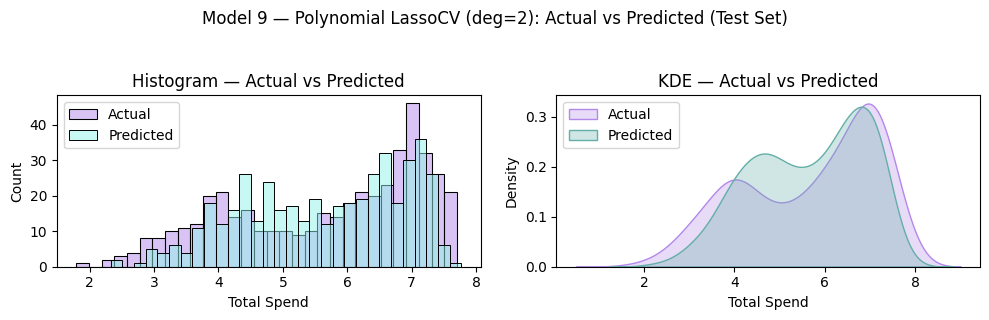

In [39]:
# ============================================================
# Model 9 — Polynomial LassoCV (deg=2)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 9 — Polynomial LassoCV (deg=2): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 10 — Polynomial Lasso (degree = 2, fixed α)

In [41]:
# ============================================================
# Model 10 — Polynomial Lasso (Fixed Alpha, degree = 2)
# ============================================================

# ------------------------------------------------------------
# Fixed alpha (choose from Model 9 inspection)
# ------------------------------------------------------------

alpha_fixed = 0.02

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=100000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline (SAME AS Model 7 & 8 + Fixed Lasso)
# ------------------------------------------------------------

pipe_poly_lasso_m10 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly),   # LOCKED (Family 2)
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation (outer)
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_poly_lasso_m10,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_poly_lasso_m10.fit(X_train, y_train)

y_train_pred = pipe_poly_lasso_m10.predict(X_train)
y_test_pred  = pipe_poly_lasso_m10.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO coefficients)
# ------------------------------------------------------------

X_train_built = pipe_poly_lasso_m10.named_steps["feature_builder"].transform(X_train)
X_train_pre   = pipe_poly_lasso_m10.named_steps["preprocessor"].transform(X_train_built)
X_train_poly  = pipe_poly_lasso_m10.named_steps["poly"].transform(X_train_pre)

feature_names = pipe_poly_lasso_m10.named_steps["poly"].get_feature_names_out(
    pipe_poly_lasso_m10.named_steps["preprocessor"].get_feature_names_out()
)

coefs = pipe_poly_lasso_m10.named_steps["regressor"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if abs(coef) > 1e-8
]

selected_sorted = sorted(
    selected, key=lambda x: abs(x[1]), reverse=True
)

feature_count = len(selected_sorted)

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m10 = {
    "model": "Model 10 — Polynomial Lasso (Fixed α, deg=2)",
    "family": "Polynomial Lasso",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "alpha_fixed": alpha_fixed,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 10 — Polynomial Lasso (Fixed α, deg=2)")
print(f"Fixed α : {alpha_fixed:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nSelected (non-zero) polynomial features: {feature_count}")
print("\nTop selected features:")
for name, coef in selected_sorted[:15]:
    print(f"{name:65s}  coef = {coef:+.4f}")


Model 10 — Polynomial Lasso (Fixed α, deg=2)
Fixed α : 0.020000
R² test : 0.712
R² train: 0.697
R² CV   : 0.695

Selected (non-zero) polynomial features: 5

Top selected features:
Income                                                             coef = +1.0311
Kidhome                                                            coef = -0.2644
Kidhome Teenhome                                                   coef = -0.0813
Age Kidhome                                                        coef = -0.0533
Income^2                                                           coef = -0.0488


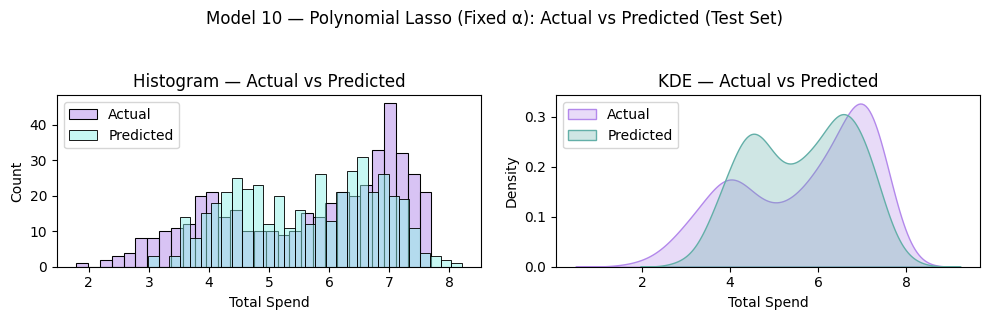

In [42]:
# ============================================================
# Model 10 — Polynomial Lasso (Fixed α)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 10 — Polynomial Lasso (Fixed α): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 11 — Linear Regression (on Polynomial Lasso–selected features)

In [43]:
# ============================================================
# Model 11 — Linear Regression
# Polynomial Lasso-selected features (Fixed α = 25)
# ============================================================
# ============================================================
# Mask-based feature selector (for Lasso-selected features)
# ============================================================

from sklearn.base import BaseEstimator, TransformerMixin

class LassoFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, coef_mask):
        self.coef_mask = coef_mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[:, self.coef_mask]

# ------------------------------------------------------------
# 1) Extract Lasso mask from Model 10 (Fixed α = 0.02)
# ------------------------------------------------------------

lasso_coefs = pipe_poly_lasso_m10.named_steps["regressor"].coef_
lasso_mask = np.abs(lasso_coefs) > 1e-8
feature_count = int(lasso_mask.sum())

# ------------------------------------------------------------
# 2) Feature selector (mask-based)
# ------------------------------------------------------------

lasso_selector = LassoFeatureSelector(coef_mask=lasso_mask)

# ------------------------------------------------------------
# 3) Pipeline: SAME preprocessing → selection → LinearRegression
# ------------------------------------------------------------

pipe_lr_m11 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly),      # SAME as Model 10
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso_select", lasso_selector),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# 4) Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m11,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# 5) Fit & Predict
# ------------------------------------------------------------

pipe_lr_m11.fit(X_train, y_train)

y_train_pred = pipe_lr_m11.predict(X_train)
y_test_pred  = pipe_lr_m11.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# 6) Coefficients with feature names
# ------------------------------------------------------------

X_train_built = pipe_lr_m11.named_steps["feature_builder"].transform(X_train)
X_train_pre   = pipe_lr_m11.named_steps["preprocessor"].transform(X_train_built)
X_train_poly  = pipe_lr_m11.named_steps["poly"].transform(X_train_pre)

all_feature_names = pipe_lr_m11.named_steps["poly"].get_feature_names_out(
    pipe_lr_m11.named_steps["preprocessor"].get_feature_names_out()
)

selected_feature_names = all_feature_names[lasso_mask]
coefs = pipe_lr_m11.named_steps["regressor"].coef_

coef_table = sorted(
    zip(selected_feature_names, coefs),
    key=lambda x: abs(x[1]),
    reverse=True
)

# ------------------------------------------------------------
# 7) Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m11 = {
    "model": "Model 11 — Linear Regression (Poly Lasso-selected, α=25)",
    "family": "Linear on Poly-selected",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "alpha_fixed": 25,
}

# ------------------------------------------------------------
# 8) Report
# ------------------------------------------------------------

print("Model 11 — Linear Regression (Poly Lasso-selected, α=25)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nFinal feature count: {feature_count}")
print("\nTop coefficients:")
for name, coef in coef_table[:20]:
    print(f"{name:65s}  coef = {coef:+.4f}")


Model 11 — Linear Regression (Poly Lasso-selected, α=25)
R² test : 0.714
R² train: 0.712
R² CV   : 0.710

Final feature count: 5

Top coefficients:
Income                                                             coef = +1.8307
Income^2                                                           coef = -0.8420
Kidhome                                                            coef = -0.2205
Kidhome Teenhome                                                   coef = -0.1386
Age Kidhome                                                        coef = -0.0674


### 4.3. Decision Tree Models (Models 12–15)

Decision Trees are used to model non-linear relationships and feature interactions
without imposing structural assumptions.
In this section, all available features are included to allow the tree
to freely discover relevant splits, while controlling complexity to
prevent overfitting within a leakage-safe evaluation framework.

#### Model 12 — Regression Tree (DecisionTreeRegressor)

In [44]:
# ============================================================
# Model 12 — Regression Tree
# Variant A: Behavioral
# ============================================================

pipe_tree_m12 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # LOCKED
    ("regressor", DecisionTreeRegressor(random_state=42))
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_tree_m12,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_tree_m12.fit(X_train, y_train)

y_train_pred = pipe_tree_m12.predict(X_train)
y_test_pred  = pipe_tree_m12.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

tree_est = pipe_tree_m12.named_steps["regressor"]

X_train_built = pipe_tree_m12.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_tree_m12.named_steps["preprocessor"].transform(X_train_built)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Store results (for final comparison table)
# ------------------------------------------------------------

results_m12 = {
    "model": "Model 12 — Regression Tree",
    "family": "Tree",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "tree_depth": tree_est.get_depth(),
    "n_leaves": tree_est.get_n_leaves()
}

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 12 — Regression Tree (Variant A)")
print(f"Tree depth : {tree_est.get_depth()}")
print(f"Leaves     : {tree_est.get_n_leaves()}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {r2_cv:.3f}")


Model 12 — Regression Tree (Variant A)
Tree depth : 22
Leaves     : 1645
R² test    : 0.555
R² train   : 1.000
R² CV      : 0.547


**Observation**

The regression tree shows clear signs of overfitting.

Although the model achieves a very high R² on the training set,
its performance drops substantially on the test set and in cross-validation.

This gap indicates that the tree is:

- fitting the training data too closely,

- learning noise and very specific splits,

- and failing to generalize to unseen customers.

This behavior is expected for an unconstrained decision tree, especially with:

- a limited number of profile features,

- no regularization (e.g. max_depth, min_samples_leaf).

As a result, this model should be treated as a high-variance baseline,
motivating the use of pruning or ensemble methods (e.g. Random Forest) in the next steps.


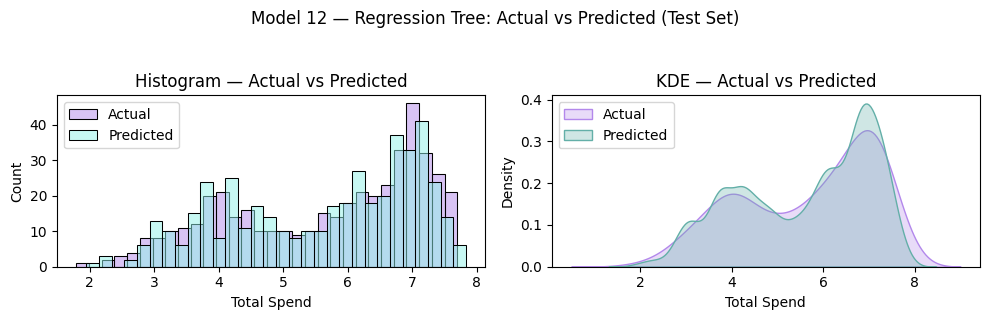

In [45]:
# ============================================================
# Model 12 — Regression Tree
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3, 
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    bw_adjust=0.5,   # 👈 
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 12 — Regression Tree: Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


Although the regression tree achieves a moderate R² on the test set, the KDE plot shows substantial overlap between actual and predicted distributions. This is expected due to the piecewise-constant nature of decision trees, which produce discrete prediction levels rather than smooth distributions.

#### Model 13 — Tuned Regression Tree (GridSearchCV) 

In [46]:
# ============================================================
# Model 13 — Tuned Regression Tree
# Variant A: Behavioral
# ============================================================

pipe_tree_m13 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED tree preprocessor
    ("regressor", DecisionTreeRegressor(random_state=42))
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------

param_grid = {
    "regressor__max_depth": [4, 6, 8, 10, 12],
    "regressor__min_samples_leaf": [2, 4, 6, 8, 10, 12],
    "regressor__min_samples_split": [2, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_tree_m13,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit GridSearch (TRAIN ONLY)
# ------------------------------------------------------------

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Fit & Predict (best model)
# ------------------------------------------------------------

y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_est = best_model.named_steps["regressor"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Feature count (pipeline-consistent)
# ------------------------------------------------------------

X_train_built = best_model.named_steps["feature_builder"].transform(X_train)
X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train_built)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Store results (for final comparison table)
# ------------------------------------------------------------

results_m13 = {
    "model": "Model 13 — Tuned Regression Tree",
    "family": "Tree",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": best_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "tree_depth": tree_depth,
    "n_leaves": tree_leaves,
    "best_params": best_params
}

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 13 — Tuned Regression Tree (Variant A)")
print("Best params:", best_params)
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {best_cv:.3f}")
print(f"Total features used: {feature_count}")


Model 13 — Tuned Regression Tree (Variant A)
Best params: {'regressor__max_depth': 4, 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 2}
Tree depth : 4
Leaves     : 15
R² test    : 0.719
R² train   : 0.755
R² CV      : 0.720
Total features used: 15


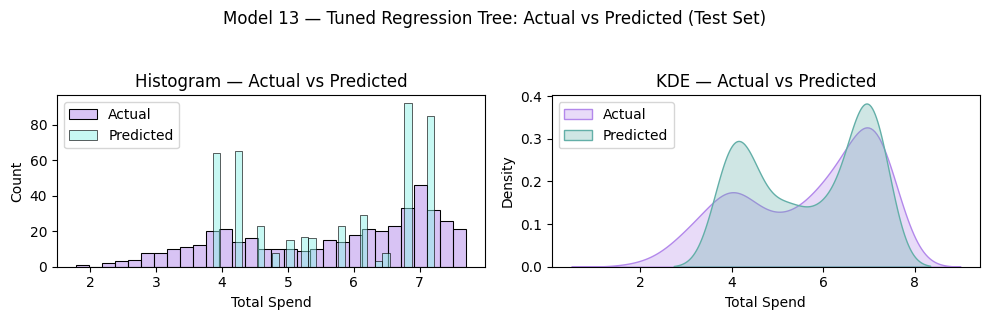

In [47]:
# ============================================================
# Model 13 — Tuned Regression Tree
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    #bw_adjust=0.5,   # 👈 
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 13 — Tuned Regression Tree: Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 14 — Regression Tree (Cost-Complexity Pruning)

In [48]:
# ============================================================
# Model 14 — Regression Tree (CCP Pruned)
# Full feature set
# ============================================================

# ------------------------------------------------------------
# Base tree (to extract CCP path)
# ------------------------------------------------------------

pipe_base = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED
    ("regressor", DecisionTreeRegressor(random_state=42))
])

pipe_base.fit(X_train, y_train)

# ------------------------------------------------------------
# Extract transformed design matrix for CCP path
# ------------------------------------------------------------

X_train_built = pipe_base.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_base.named_steps["preprocessor"].transform(X_train_built)

tree_est = pipe_base.named_steps["regressor"]

ccp_path = tree_est.cost_complexity_pruning_path(
    X_train_transformed, y_train
)

ccp_alphas = ccp_path.ccp_alphas[:-1]   # drop max alpha

# Numerical stability: enforce non-negative ccp_alpha
ccp_alphas = np.clip(ccp_alphas, 0.0, None)

# ------------------------------------------------------------
# CV to select best ccp_alpha (TRAIN ONLY)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for alpha in ccp_alphas:
    pipe_tmp = Pipeline(steps=[
        ("feature_builder", DeterministicFeatureBuilder()),
        ("preprocessor", preprocessor_tree),
        ("regressor", DecisionTreeRegressor(
            random_state=42,
            ccp_alpha=alpha
        ))
    ])

    score = cross_val_score(
        pipe_tmp,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=1
    ).mean()

    cv_scores.append(score)

best_alpha = ccp_alphas[int(np.argmax(cv_scores))]
best_cv = float(np.max(cv_scores))

# ------------------------------------------------------------
# Fit final pruned tree
# ------------------------------------------------------------

pipe_tree_m14 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),
    ("regressor", DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=best_alpha
    ))
])

pipe_tree_m14.fit(X_train, y_train)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = pipe_tree_m14.predict(X_train)
y_test_pred  = pipe_tree_m14.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_final = pipe_tree_m14.named_steps["regressor"]
tree_depth = tree_final.get_depth()
tree_leaves = tree_final.get_n_leaves()

# ------------------------------------------------------------
# Feature count (pipeline-consistent)
# ------------------------------------------------------------

X_train_built = pipe_tree_m14.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_tree_m14.named_steps["preprocessor"].transform(X_train_built)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Store results (for final comparison table)
# ------------------------------------------------------------

results_m14 = {
    "model": "Model 14 — Regression Tree (CCP Pruned)",
    "family": "Tree",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": best_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
    "tree_depth": tree_depth,
    "n_leaves": tree_leaves,
    "ccp_alpha": best_alpha
}

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 14 — Regression Tree (CCP Pruned)")
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth     : {tree_depth}")
print(f"Leaves         : {tree_leaves}")
print(f"R² test        : {r2_test:.3f}")
print(f"R² train       : {r2_train:.3f}")
print(f"R² CV          : {best_cv:.3f}")
print(f"Total features used: {feature_count}")


Model 14 — Regression Tree (CCP Pruned)
Best ccp_alpha : 0.014762
Tree depth     : 3
Leaves         : 6
R² test        : 0.696
R² train       : 0.723
R² CV          : 0.704
Total features used: 15


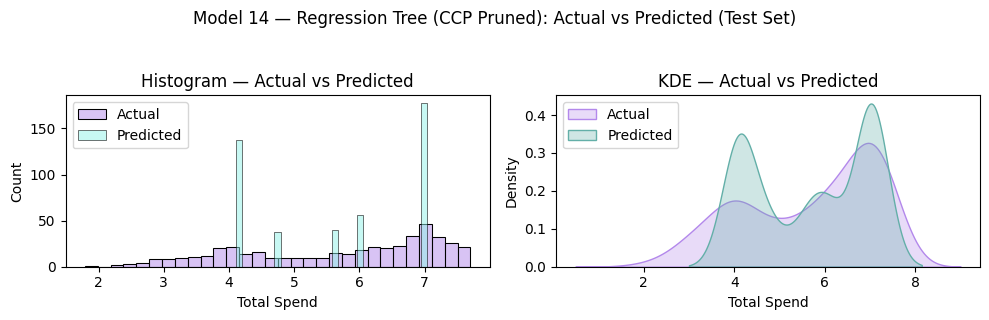

In [49]:
# ============================================================
# Model 14 — Regression Tree (CCP Pruned)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 14 — Regression Tree (CCP Pruned): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 15 — Regression Tree (Fixed CCP Alpha)

In [50]:
# ============================================================
# Model 15 — Regression Tree (Fixed CCP Alpha)
# ============================================================

# ------------------------------------------------------------
# Fixed CCP alpha (from Model 14)
# ------------------------------------------------------------

ccp_alpha_fixed = 0.014762

# ------------------------------------------------------------
# Pipeline (LOCKED tree preprocessing)
# ------------------------------------------------------------

pipe_tree_m15 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=ccp_alpha_fixed
    ))
])

# ------------------------------------------------------------
# Cross-validation (TRAIN ONLY)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_tree_m15,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_tree_m15.fit(X_train, y_train)

y_train_pred = pipe_tree_m15.predict(X_train)
y_test_pred  = pipe_tree_m15.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_est = pipe_tree_m15.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Feature count (pipeline-consistent)
# ------------------------------------------------------------

X_train_built = pipe_tree_m15.named_steps["feature_builder"].transform(X_train)
X_train_transformed = pipe_tree_m15.named_steps["preprocessor"].transform(X_train_built)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Store results (NO LOGGING)
# ------------------------------------------------------------

results_m15 = {
    "model": "Model 15 — Regression Tree (Fixed CCP)",
    "family": "Decision Tree",
    "ccp_alpha": ccp_alpha_fixed,
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "tree_depth": tree_depth,
    "tree_leaves": tree_leaves,
    "feature_count": feature_count
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 15 — Regression Tree (Fixed CCP)")
print(f"Fixed ccp_alpha : {ccp_alpha_fixed}")
print(f"Tree depth      : {tree_depth}")
print(f"Leaves          : {tree_leaves}")
print(f"R² test         : {r2_test:.3f}")
print(f"R² train        : {r2_train:.3f}")
print(f"R² CV           : {r2_cv:.3f}")
print(f"Total features  : {feature_count}")


Model 15 — Regression Tree (Fixed CCP)
Fixed ccp_alpha : 0.014762
Tree depth      : 3
Leaves          : 6
R² test         : 0.696
R² train        : 0.723
R² CV           : 0.704
Total features  : 15


### 4.4.Ensemble Tree-Based Models (Models 16-19)
Single decision trees are interpretable but prone to overfitting and instability.
Ensemble tree-based models combine multiple trees to improve robustness and
generalization.

#### Model 16 — Base Random Forest Regressor

(200 trees, OOB, leakage-safe)

In [51]:
# ============================================================
# Model 16 — Random Forest (Base)
# ============================================================

# ------------------------------------------------------------
# Pipeline (LOCKED tree preprocessing)
# ------------------------------------------------------------

pipe_rf_m16 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 locked tree preprocessor
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------

pipe_rf_m16.fit(X_train, y_train)

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

y_train_pred = pipe_rf_m16.predict(X_train)
y_test_pred  = pipe_rf_m16.predict(X_test)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

oob_r2 = pipe_rf_m16.named_steps["regressor"].oob_score_

# ------------------------------------------------------------
# Feature count (pipeline-consistent)
# ------------------------------------------------------------

X_tmp = pipe_rf_m16.named_steps["preprocessor"].transform(
    pipe_rf_m16.named_steps["feature_builder"].transform(X_train)
)

feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT — no logging)
# ------------------------------------------------------------

results_m16 = {
    "model": "Model 16 — Random Forest (Base)",
    "family": "Random Forest",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": oob_r2,          # OOB used as CV proxy
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 16 — Random Forest (Base)")
print(f"OOB R²   : {oob_r2:.3f}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"Features : {feature_count}")


Model 16 — Random Forest (Base)
OOB R²   : 0.734
R² test  : 0.733
R² train : 0.964
Features : 15


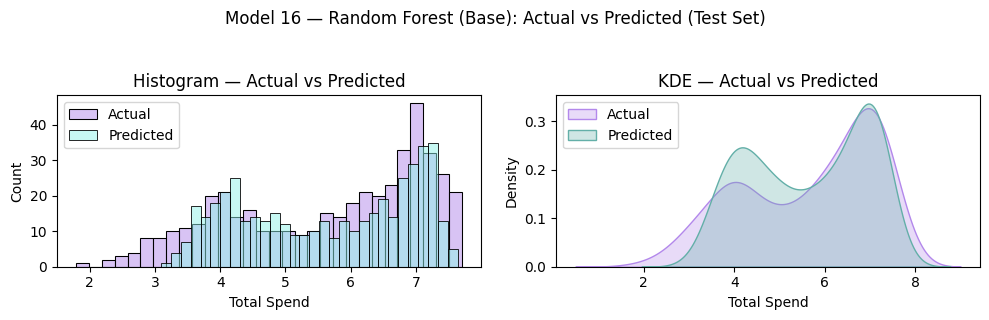

In [52]:
# ============================================================
# Model 16 — Random Forest (Base)
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 16 — Random Forest (Base): Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 17 — Tuned Random Forest Regressor (GridSearchCV)

In [53]:
# ============================================================
# Model 17 — Tuned Random Forest
# ============================================================

# ------------------------------------------------------------
# Pipeline (PROJECT-STANDARD, TREE FAMILY)
# ------------------------------------------------------------

pipe_rf_m17 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------

param_grid = {
    "rf__max_depth": [None, 10, 15, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_rf_m17,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit GridSearch (TRAIN ONLY)
# ------------------------------------------------------------

grid.fit(X_train, y_train)

best_model  = grid.best_estimator_
best_params = grid.best_params_
best_cv_r2  = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

forest = best_model.named_steps["rf"]
oob_r2 = forest.oob_score_

# ------------------------------------------------------------
# Feature count (leakage-safe)
# ------------------------------------------------------------

X_tmp = preprocessor_tree.transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Tree diagnostics (averaged)
# ------------------------------------------------------------

tree_depths = [est.tree_.max_depth for est in forest.estimators_]
leaf_counts = [(est.tree_.children_left == -1).sum() for est in forest.estimators_]

mean_depth  = float(np.mean(tree_depths))
mean_leaves = float(np.mean(leaf_counts))

# ------------------------------------------------------------
# Store results (STANDARD FORMAT — no logging)
# ------------------------------------------------------------

results_m17 = {
    "model": "Model 17 — Tuned Random Forest",
    "family": "Random Forest",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": best_cv_r2,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings(
    "ignore",
    message="The number of unique classes is greater than 50% of the number of samples"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 17 — Tuned Random Forest")
print(f"Best params:              {best_params}")
print(f"OOB R²:                   {oob_r2:.3f}")
print(f"R² train:                 {r2_train:.3f}")
print(f"R² test:                  {r2_test:.3f}")
print(f"Best CV R² (5-fold):      {best_cv_r2:.3f}")
print(f"MSE train:                {mse_train:.3f}")
print(f"MSE test:                 {mse_test:.3f}")
print(f"Mean tree depth:          {mean_depth:.1f}")
print(f"Mean leaf nodes per tree: {mean_leaves:.1f}")
print(f"Total features used:      {feature_count}")


Model 17 — Tuned Random Forest
Best params:              {'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10}
OOB R²:                   0.744
R² train:                 0.873
R² test:                  0.738
Best CV R² (5-fold):      0.740
MSE train:                0.275
MSE test:                 0.567
Mean tree depth:          10.0
Mean leaf nodes per tree: 149.6
Total features used:      15


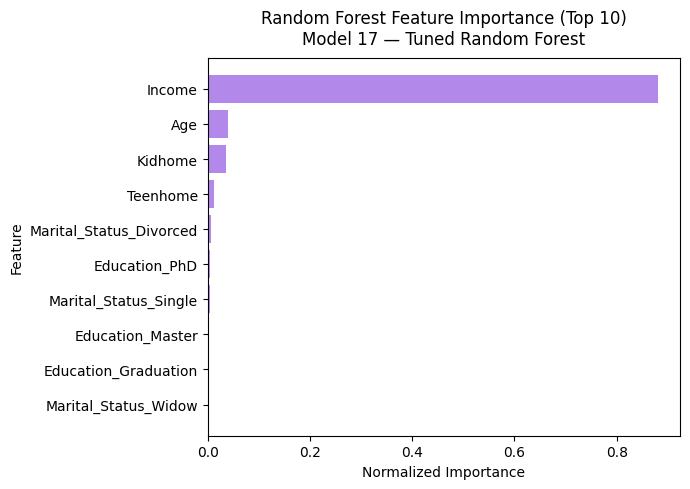

In [54]:
# ============================================================
# 🌲 Feature Importance — Random Forest
# Model 17 — Tuned Random Forest
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Extract fitted components from best model
# ------------------------------------------------------------
preprocessor = best_model.named_steps["preprocessor"]   # == preprocessor_tree
forest = best_model.named_steps["rf"]

# ------------------------------------------------------------
# Feature names AFTER preprocessing
# ------------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# Feature importances
# ------------------------------------------------------------
importances = forest.feature_importances_

feat_imp = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# (Optional) normalize for nicer plotting
feat_imp["importance_norm"] = feat_imp["importance"] / feat_imp["importance"].sum()

# ------------------------------------------------------------
# Bar plot — Top K features
# ------------------------------------------------------------
TOP_K = 10
top_feat = feat_imp.head(TOP_K).iloc[::-1]  # reverse for horizontal plot

plt.figure(figsize=(7, 5))
plt.barh(
    top_feat["feature"],
    top_feat["importance_norm"],
    color="#B388EB"
)

plt.title(
    "Random Forest Feature Importance (Top 10)\n"
    "Model 17 — Tuned Random Forest",
    pad=10
)
plt.xlabel("Normalized Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


#### Model 18 — Gradient Boosting Regressor (Baseline)

In [55]:
# ============================================================
# Model 18 — Gradient Boosting Regressor
# ============================================================

# ------------------------------------------------------------
# Pipeline (PROJECT-STANDARD, TREE FAMILY)
# ------------------------------------------------------------

pipe_gbr_m18 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),
    ("gbr", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        random_state=42
    ))
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_gbr_m18,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=1
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------

pipe_gbr_m18.fit(X_train, y_train)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = pipe_gbr_m18.predict(X_train)
y_test_pred  = pipe_gbr_m18.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (leakage-safe, consistent)
# ------------------------------------------------------------

X_tmp = preprocessor_tree.transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m18 = {
    "model": "Model 18 — Gradient Boosting",
    "family": "Gradient Boosting",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 18 — Gradient Boosting Regressor")
print(f"R² train : {r2_train:.3f}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² CV    : {r2_cv:.3f}")
print(f"MSE test : {mse_test:.1f}")
print(f"Features : {feature_count}")


Model 18 — Gradient Boosting Regressor
R² train : 0.808
R² test  : 0.742
R² CV    : 0.742
MSE test : 0.6
Features : 15


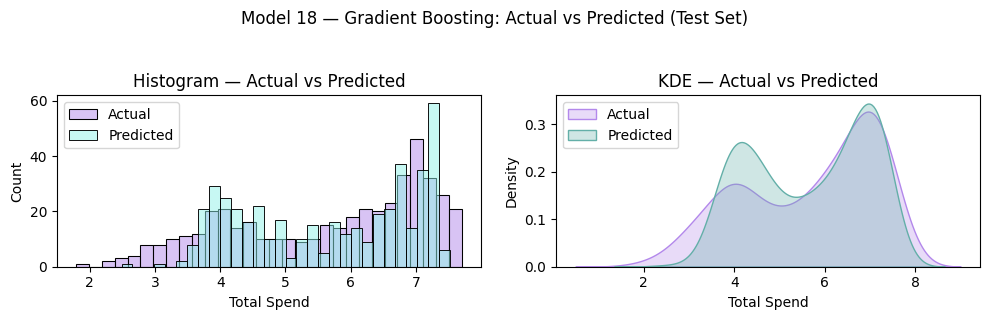

In [56]:
# ============================================================
# Model 18 — Gradient Boosting
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 18 — Gradient Boosting: Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


#### Model 19 — XGBoost Regressor (Tuned, CV)

In [57]:
# ============================================================
# Model 19 — XGBoost Regressor
# ============================================================

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# Pipeline (PROJECT-STANDARD, TREE FAMILY)
# ------------------------------------------------------------

pipe_xgb_m19 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    ))
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------

param_grid = {
    "xgb__n_estimators": [300, 500],
    "xgb__max_depth": [3, 5],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_xgb_m19,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=1   # intentionally limited (heavy model)
)

# ------------------------------------------------------------
# Fit GridSearch (TRAIN ONLY)
# ------------------------------------------------------------

grid.fit(X_train, y_train)

best_model  = grid.best_estimator_
best_params = grid.best_params_
best_cv_r2  = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (leakage-safe)
# ------------------------------------------------------------

X_tmp = preprocessor_tree.transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------

results_m19 = {
    "model": "Model 19 — XGBoost",
    "family": "XGBoost",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": best_cv_r2,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 19 — XGBoost")
print(f"Best params:         {best_params}")
print(f"R² train:            {r2_train:.3f}")
print(f"R² test:             {r2_test:.3f}")
print(f"Best CV R² (5-fold): {best_cv_r2:.3f}")
print(f"MSE train:           {mse_train:.3f}")
print(f"MSE test:            {mse_test:.3f}")
print(f"Total features:      {feature_count}")


Model 19 — XGBoost
Best params:         {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}
R² train:            0.805
R² test:             0.738
Best CV R² (5-fold): 0.739
MSE train:           0.420
MSE test:            0.568
Total features:      15


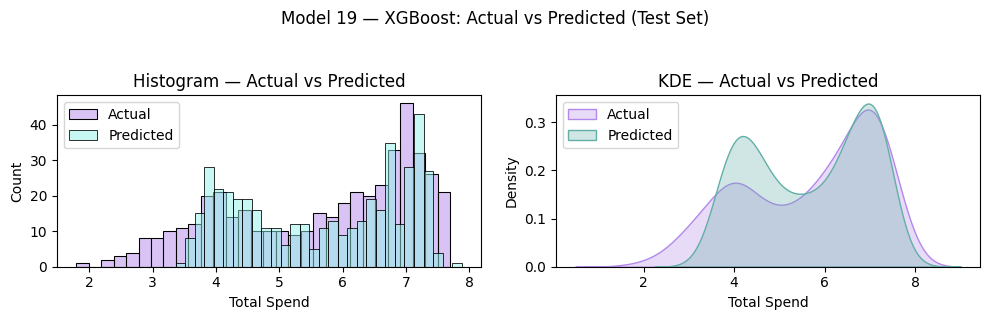

In [58]:
# ============================================================
# Model 19 — XGBoost
# Actual vs Predicted (Test Set)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ------------------------------------------------------------
# Histogram — Actual vs Predicted
# ------------------------------------------------------------

sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Histogram — Actual vs Predicted")
axes[0].set_xlabel("Total Spend")
axes[0].legend()

# ------------------------------------------------------------
# KDE — Actual vs Predicted
# ------------------------------------------------------------

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_title("KDE — Actual vs Predicted")
axes[1].set_xlabel("Total Spend")
axes[1].legend()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.suptitle(
    "Model 19 — XGBoost: Actual vs Predicted (Test Set)",
    y=1.05
)

plt.tight_layout()
plt.show()


### 4.5 Kernel-Based Regression (Models 20–21)

#### Model 20 — SVR (RBF)

In [59]:
# ============================================================
# Model 20 — Support Vector Regression (RBF)
# ============================================================

# ------------------------------------------------------------
# Target (log-scale REQUIRED for SVR)
# ------------------------------------------------------------
y_train_m20 = y_train
y_test_m20  = y_test

# ------------------------------------------------------------
# Pipeline (DISTANCE-BASED, CORRECT ORDER)
# ------------------------------------------------------------
pipe_svr_m20 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_svr),   # locked numeric+OHE+scaling
    ("svr", SVR(
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
    ))
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_svr_m20,
    X_train,
    y_train_m20,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_svr_m20.fit(X_train, y_train_m20)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_svr_m20.predict(X_train)
y_test_pred  = pipe_svr_m20.predict(X_test)

r2_train = r2_score(y_train_m20, y_train_pred)
r2_test  = r2_score(y_test_m20, y_test_pred)

mse_train = mean_squared_error(y_train_m20, y_train_pred)
mse_test  = mean_squared_error(y_test_m20, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------
X_tmp = preprocessor_svr.transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Store results (STANDARD FORMAT)
# ------------------------------------------------------------
results_m20 = {
    "model": "Model 20 — SVR (RBF)",
    "family": "SVR",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 20 — SVR (RBF)")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"R² CV    : {r2_cv:.3f}")
print(f"Features : {feature_count}")


Model 20 — SVR (RBF)
R² test  : 0.734
R² train : 0.776
R² CV    : 0.732
Features : 4


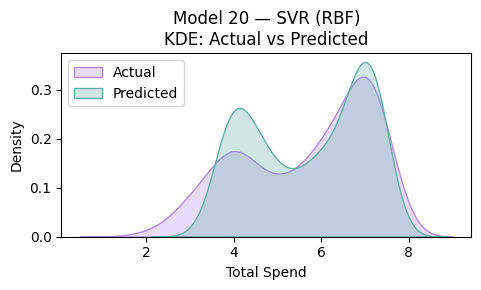

In [60]:
# ============================================================
# Model 20 — KDE (Actual vs Predicted)
# SVR (RBF)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=ax
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=ax
)

ax.set_title(
    "Model 20 — SVR (RBF)\nKDE: Actual vs Predicted"
)
ax.set_xlabel("Total Spend")
ax.legend()

plt.tight_layout()
plt.show()


#### Model 21 — SVR (RBF)(on Polynomial Lasso–selected features)

In [61]:
# ============================================================
# Model 21 — SVR (RBF)
# Polynomial Lasso-selected Features
# ============================================================

import numpy as np
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin


# ------------------------------------------------------------
# 1) Extract Lasso mask from Model 9 (Polynomial LassoCV)
# ------------------------------------------------------------

lasso_coefs = pipe_poly_lasso_m9.named_steps["regressor"].coef_
lasso_mask  = np.abs(lasso_coefs) > 1e-8
feature_count = int(lasso_mask.sum())


# ------------------------------------------------------------
# 2) Mask-based feature selector
# ------------------------------------------------------------

class MaskFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, mask):
        self.mask = mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[:, self.mask]


# ------------------------------------------------------------
# 3) Pipeline — SVR (RBF) on selected polynomial features
# ------------------------------------------------------------

pipe_svr_m21 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly),   # locked polynomial preprocessor
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("select", MaskFeatureSelector(mask=lasso_mask)),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
    ))
])


# ------------------------------------------------------------
# 4) Cross-validation (train only)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_svr_m21,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()


# ------------------------------------------------------------
# 5) Fit & Predict
# ------------------------------------------------------------

pipe_svr_m21.fit(X_train, y_train)

y_train_pred = pipe_svr_m21.predict(X_train)
y_test_pred  = pipe_svr_m21.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)


# ------------------------------------------------------------
# 6) Store results (STANDARD FORMAT — no logging)
# ------------------------------------------------------------

results_m21 = {
    "model": "Model 21 — SVR (RBF, Poly Lasso-selected)",
    "family": "SVR",
    "r2_train": r2_train,
    "r2_test": r2_test,
    "r2_cv": r2_cv,
    "mse_train": mse_train,
    "mse_test": mse_test,
    "feature_count": feature_count,
}


# ------------------------------------------------------------
# 7) Report
# ------------------------------------------------------------

print("Model 21 — SVR (RBF, Poly Lasso-selected)")
print(f"R² test   : {r2_test:.3f}")
print(f"R² train  : {r2_train:.3f}")
print(f"R² CV     : {r2_cv:.3f}")
print(f"Features  : {feature_count}")


Model 21 — SVR (RBF, Poly Lasso-selected)
R² test   : 0.736
R² train  : 0.774
R² CV     : 0.732
Features  : 14


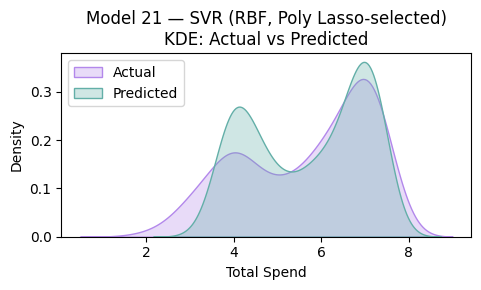

In [62]:
# ============================================================
# Model 21 — KDE (Actual vs Predicted)
# SVR (RBF, Poly Lasso-selected)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=ax
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8",
    fill=True,
    alpha=0.3,
    ax=ax
)

ax.set_title(
    "Model 21 — SVR (RBF, Poly Lasso-selected)\nKDE: Actual vs Predicted"
)
ax.set_xlabel("Total Spend")
ax.legend()

plt.tight_layout()
plt.show()


## 5. Final Model Comparison — Regression

In [63]:
# ============================================================
# Final Model Comparison — Ranked by R² Test
# Algorithmic Family Coloring (Linear / Tree / Forest / Boosting / Kernel)
# ============================================================

import pandas as pd
from IPython.display import display, HTML

# ------------------------------------------------------------
# 1) Collect results (assumes results_m1 ... results_m21 exist)
# ------------------------------------------------------------

results_all = [
    results_m1, results_m2, results_m3, results_m4, results_m5,
    results_m6, results_m7, results_m8, results_m9, results_m10,
    results_m11, results_m12, results_m13, results_m14, results_m15,
    results_m16, results_m17, results_m18, results_m19, results_m20,
    results_m21,
]

df = pd.DataFrame(results_all)

# ------------------------------------------------------------
# 2) Rank by R² test
# ------------------------------------------------------------

df = (
    df
    .sort_values("r2_test", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3) Algorithmic family extraction (STRICT & CLEAN)
# ------------------------------------------------------------

def extract_family(model_name):

    name = model_name.lower()

    if "svr" in name or "svm" in name:
        return "Kernel"

    if "random forest" in name:
        return "Forest"

    if "boost" in name or "xgboost" in name:
        return "Boosting"

    if "tree" in name:
        return "Tree"

    # everything linear, regularized, polynomial, selected
    return "Linear"


df["Archetype"] = df["model"].apply(extract_family)

# ------------------------------------------------------------
# 4) Color palette (your requested vibe)
# ------------------------------------------------------------

archetype_colors = {
    "Linear":   "#FBE9E7",
    "Kernel":   "#C5CCD1",
    "Tree":     "#E8F5E9",
    "Forest":   "#FFFDE7",
    "Boosting": "#D5B6DA",
}

def highlight_archetype(row):
    color = archetype_colors.get(row["Archetype"], "#FFFFFF")
    return [f"background-color: {color}"] * len(row)

def highlight_r2(col):
    return [
        "background-color: #FFCDD2; font-weight:600"
        if col.name == "r2_test" else ""
        for _ in col
    ]

# ------------------------------------------------------------
# 5) Styled table
# ------------------------------------------------------------

styled_df = (
    df[
        [
            "model",
            "r2_test",
            "r2_train",
            "r2_cv",
            "mse_test",
            "feature_count",
            "Archetype",
        ]
    ]
    .style
    .apply(highlight_archetype, axis=1)
    .apply(highlight_r2, axis=0)
    .format({
        "r2_test": "{:.3f}",
        "r2_train": "{:.3f}",
        "r2_cv": "{:.3f}",
        "mse_test": "{:.0f}",
    })
)

# ------------------------------------------------------------
# 6) Display
# ------------------------------------------------------------

display(HTML("""
<h3 style="text-align:center; font-weight:600; margin-bottom:6px;">
Final Model Comparison — Ranked by R² Test
</h3>
"""))

display(styled_df)

,model,r2_test,r2_train,r2_cv,mse_test,feature_count,Archetype
0,Model 18 — Gradient Boosting,0.742,0.808,0.742,1,15,Boosting
1,Model 17 — Tuned Random Forest,0.738,0.873,0.740,1,15,Forest
2,Model 19 — XGBoost,0.738,0.805,0.739,1,15,Boosting
3,"Model 21 — SVR (RBF, Poly Lasso-selected)",0.736,0.774,0.732,1,14,Kernel
4,Model 20 — SVR (RBF),0.734,0.776,0.732,1,4,Kernel
5,Model 16 — Random Forest (Base),0.733,0.964,0.734,1,15,Forest
6,Model 9 — Polynomial LassoCV (deg=2),0.721,0.718,0.713,1,14,Linear
7,Model 8 — Polynomial Ridge Regression (deg=2),0.720,0.719,0.713,1,14,Linear
8,Model 7 — Polynomial Linear Regression (deg=2),0.720,0.719,0.713,1,14,Linear
9,Model 13 — Tuned Regression Tree,0.719,0.755,0.720,1,15,Tree
